# SHAP, Control de Overfitting, Calibración y Umbral

Pipeline completo aplicado a los **top-3 modelos** del Sprint 2. El objetivo es obtener, para cada modelo, una versión optimizada con features seleccionadas, hiperparámetros re-optimizados, probabilidades calibradas y umbral de decisión ajustado. Al final se selecciona un **campeón** por F1_CV y se evalúa una única vez contra el hold-out.

## Configuración

In [2]:
import warnings, os, json, time, platform
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import skew

from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve, brier_score_loss)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

def coral(s):
    return f'\033[38;2;255;127;80m{s}\033[0m'

# ── Subcarpetas de outputs ──
OUT = 'outputs_sprint3'
DIR_DATA   = f'{OUT}/data'
DIR_MODELS = f'{OUT}/models'
DIR_FIG    = f'{OUT}/figures'
DIR_TAB    = f'{OUT}/tables'
for d in [DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB]:
    os.makedirs(d, exist_ok=True)

METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR']
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(coral('Sprint 3 — configuración cargada.'))

Sprint 3 — configuración cargada.


## Versiones de librerías

In [3]:
import sklearn, imblearn
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'xgboost': xgb.__version__, 'lightgbm': lgb.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__,
    'shap': shap.__version__, 'optuna': optuna.__version__, 'joblib': joblib.__version__,
}
try:
    import catboost; versiones['catboost'] = catboost.__version__
except: pass
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  xgboost           : 3.3.0
  lightgbm          : 4.6.0
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  shap              : 0.52.0
  optuna            : 4.9.0
  joblib            : 1.5.3
  catboost          : 1.2.10


## Carga de artefactos del Sprint 2

In [4]:
# ── Resúmenes ──
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)
with open('outputs_sprint1/resumen_sprint1.json') as f:
    RESUMEN_S1 = json.load(f)
with open('outputs_sprint2/resumen_sprint2.json') as f:
    RESUMEN_S2 = json.load(f)

FEATURES_BASE = RESUMEN_S0['features']
F1_SPRINT2    = RESUMEN_S2['f1_cv_final']
TOP_3         = RESUMEN_S2['top_3']

# ── Índices del split (persistidos por S0) ──
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')

# ── Dataset procesado ──
df = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

# ── Top-3 config (set, balanceo, params, f1_cv) ──
with open('outputs_sprint2/data/top3_config.json') as f:
    TOP3_CONFIG = json.load(f)

# ── Sets de features por experimento ──
with open('outputs_sprint2/data/sets_features.json') as f:
    SETS_FEATURES = json.load(f)

print(f'Features base: {len(FEATURES_BASE)} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Prevalencia positiva (train): {y_train.mean():.3f}')
print(f'F1_CV Sprint 2 (referencia): {F1_SPRINT2:.4f}')
print(f'\nTop-3 modelos del Sprint 2:')
for m in TOP_3:
    c = TOP3_CONFIG[m]
    print(f'  {m:22s}: set={c["set"]}, bal={c["balanceo"]}, f1_cv={c["f1_cv"]:.4f}')

Features base: 46 | Train: (1705, 46) | Test: (427, 46)
Prevalencia positiva (train): 0.122
F1_CV Sprint 2 (referencia): 0.7493

Top-3 modelos del Sprint 2:
  CatBoost              : set=E0 Base, bal=RandomOverSampler, f1_cv=0.7493
  XGBoost               : set=E0 Base, bal=RandomOverSampler, f1_cv=0.7440
  HistGradientBoosting  : set=E2 +Cluster RAW, bal=RandomOverSampler, f1_cv=0.7428


## Reconstrucción de features sets para cada modelo del top-3

Cada modelo del top-3 puede operar sobre un set de features distinto (E0 Base, E2 +Cluster RAW, etc.). Se reconstruyen los sets necesarios cargando los modelos de clustering ya ajustados en el Sprint 2 (no se reajustan).

In [5]:
# ── Cargar modelos de clustering (ajustados en S2) ──
modelos_cl_raw = joblib.load('outputs_sprint2/models/clustering_raw.pkl')
modelos_cl_log = joblib.load('outputs_sprint2/models/clustering_log.pkl')

def generar_cluster_features(Xtr_esp, Xte_esp, modelos_cl, etiqueta):
    """Genera features de cluster usando modelos YA ajustados (cargados de S2)."""
    sc  = modelos_cl['scaler']
    km  = modelos_cl['kmeans']
    gm  = modelos_cl['gmm']
    eps = modelos_cl['eps']

    Ztr = sc.transform(Xtr_esp)
    Zte = sc.transform(Xte_esp)

    def dist_centroides(Z):
        return np.min(np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=1)

    db_tr = DBSCAN(eps=eps, min_samples=10).fit_predict(Ztr)
    db_te = DBSCAN(eps=eps, min_samples=10).fit_predict(Zte)

    ftr = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Ztr) if hasattr(km, 'predict') else km.labels_,
        f'kmeans_dist_{etiqueta}': dist_centroides(Ztr),
        f'gmm_label_{etiqueta}': gm.predict(Ztr),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Ztr).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_tr == -1).astype(int),
    }, index=Xtr_esp.index)
    fte = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Zte),
        f'kmeans_dist_{etiqueta}': dist_centroides(Zte),
        f'gmm_label_{etiqueta}': gm.predict(Zte),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Zte).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_te == -1).astype(int),
    }, index=Xte_esp.index)
    return ftr, fte

# ── Construir los sets necesarios ──
NO_ECON = RESUMEN_S2['elementos_no_economicos']
sets_needed = set(TOP3_CONFIG[m]['set'] for m in TOP_3)
print(f'Sets necesarios: {sets_needed}')

# E0 Base siempre está disponible (= X_train/X_test con FEATURES_BASE)
SETS_TR, SETS_TE = {}, {}
SETS_TR['E0 Base'] = X_train.copy()
SETS_TE['E0 Base'] = X_test.copy()

if 'E2 +Cluster RAW' in sets_needed:
    Xtr_raw = X_train[NO_ECON].copy()
    Xte_raw = X_test[NO_ECON].copy()
    cl_raw_tr, cl_raw_te = generar_cluster_features(Xtr_raw, Xte_raw, modelos_cl_raw, 'raw')
    SETS_TR['E2 +Cluster RAW'] = pd.concat([X_train, cl_raw_tr], axis=1)
    SETS_TE['E2 +Cluster RAW'] = pd.concat([X_test, cl_raw_te], axis=1)
    print(f'  E2 +Cluster RAW: {SETS_TR["E2 +Cluster RAW"].shape[1]} features')

if 'E4 +Cluster LOG' in sets_needed:
    Xtr_log = np.log1p(X_train[NO_ECON].clip(lower=0))
    Xte_log = np.log1p(X_test[NO_ECON].clip(lower=0))
    cl_log_tr, cl_log_te = generar_cluster_features(Xtr_log, Xte_log, modelos_cl_log, 'log')
    SETS_TR['E4 +Cluster LOG'] = pd.concat([X_train, cl_log_tr], axis=1)
    SETS_TE['E4 +Cluster LOG'] = pd.concat([X_test, cl_log_te], axis=1)

for m in TOP_3:
    s = TOP3_CONFIG[m]['set']
    print(f'  {m}: {s} → {SETS_TR[s].shape[1]} features')

Sets necesarios: {'E0 Base', 'E2 +Cluster RAW'}


  E2 +Cluster RAW: 51 features
  CatBoost: E0 Base → 46 features
  XGBoost: E0 Base → 46 features
  HistGradientBoosting: E2 +Cluster RAW → 51 features


## Funciones auxiliares

Se definen funciones para instanciar clasificadores, construir pipelines con balanceo y evaluar F1_CV.

In [6]:
def crear_clf(mod, params):
    """Instancia un clasificador con los hiperparámetros dados."""
    if mod == 'CatBoost':
        return CatBoostClassifier(**params, random_seed=SEED, verbose=0, allow_writing_files=False)
    if mod == 'XGBoost':
        return xgb.XGBClassifier(**params, random_state=SEED, eval_metric='logloss',
                                 tree_method='hist', n_jobs=-1)
    if mod == 'HistGradientBoosting':
        from sklearn.ensemble import HistGradientBoostingClassifier
        return HistGradientBoostingClassifier(**params, random_state=SEED)
    if mod == 'LightGBM':
        return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)
    raise ValueError(f'Modelo no soportado: {mod}')

def make_pipe(mod, params, balanceo='RandomOverSampler'):
    """Pipeline: StandardScaler → Balanceo → Clasificador."""
    if balanceo == 'RandomOverSampler':
        bal = RandomOverSampler(random_state=SEED)
    else:
        raise ValueError(f'Balanceo no soportado: {balanceo}')
    return ImbPipeline([
        ('sc', StandardScaler()),
        ('bal', bal),
        ('clf', crear_clf(mod, params)),
    ])

def f1_cv(mod, X_in, y_in, params, balanceo='RandomOverSampler'):
    """F1 clase positiva por CV 5-fold. Devuelve (media, std)."""
    sc = cross_val_score(make_pipe(mod, params, balanceo), X_in, y_in,
                         cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

print('Helpers definidos: crear_clf, make_pipe, f1_cv')

Helpers definidos: crear_clf, make_pipe, f1_cv


## Verifiación reproducción del F1_CV del Sprint 2

Se verifica que los modelos, sobre sus respectivos sets de features y con los hiperparámetros del Sprint 2, reproduzcan exactamente el F1_CV reportado. Una discrepancia mayor a 0.002 indicaría diferencias en el entorno de ejecución.

In [7]:
print('Verificación de reproducción del F1_CV S2 para cada top-3:')
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    Xtr_m = SETS_TR[cfg['set']]
    f1_rep, sd_rep = f1_cv(m, Xtr_m, y_train, cfg['params'], cfg['balanceo'])
    delta = f1_rep - cfg['f1_cv']
    ok = 'Ok' if abs(delta) <= 0.002 else 'Error'
    print(f'  {ok} {m:22s}: F1_CV={f1_rep:.4f} ± {sd_rep:.4f} (ref={cfg["f1_cv"]:.4f}, Δ={delta:+.4f})')

Verificación de reproducción del F1_CV S2 para cada top-3:


  Ok CatBoost              : F1_CV=0.7493 ± 0.0457 (ref=0.7493, Δ=+0.0000)
  Ok XGBoost               : F1_CV=0.7440 ± 0.0487 (ref=0.7440, Δ=+0.0000)
  Ok HistGradientBoosting  : F1_CV=0.7428 ± 0.0402 (ref=0.7428, Δ=-0.0000)


## Análisis de SHAP

Se calcula SHAP (`TreeExplainer`) para cada uno de los top-3 modelos, entrenados sobre su set de features con balanceo (RandomOverSampler sobre todo el train). Los valores SHAP se calculan sobre el train original (distribución real, no la remuestreada) para que las importancias reflejen la población observada.

In [8]:
shap_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    Xtr_m = SETS_TR[cfg['set']]
    feats = list(Xtr_m.columns)

    # Entrenar con balanceo
    Xtr_res, ytr_res = RandomOverSampler(random_state=SEED).fit_resample(Xtr_m, y_train)
    clf = crear_clf(m, cfg['params'])
    clf.fit(Xtr_res, ytr_res)

    # SHAP
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(Xtr_m)
    if isinstance(sv, list):
        sv = sv[1]
    sv = np.asarray(sv)
    ev = explainer.expected_value
    base_val = float(np.asarray(ev).ravel()[-1]) if np.ndim(ev) else float(ev)

    imp = np.abs(sv).mean(axis=0)
    imp_ser = pd.Series(imp, index=feats).sort_values(ascending=False)
    imp_df = imp_ser.reset_index(); imp_df.columns = ['feature', 'mean_abs_shap']
    imp_df['cum_frac'] = imp_df['mean_abs_shap'].cumsum() / imp_df['mean_abs_shap'].sum()

    shap_results[m] = {
        'sv': sv, 'base_val': base_val, 'clf': clf,
        'imp_ser': imp_ser, 'imp_df': imp_df, 'feats': feats, 'Xtr': Xtr_m,
    }
    imp_df.to_csv(f'{DIR_TAB}/shap_importancias_{m.lower().replace(" ", "_")}.csv', index=False)
    print(f'{m} — SHAP sobre {Xtr_m.shape[1]} features:')
    print(f'  Top-5: {imp_ser.index[:5].tolist()}')
    print(f'  Features para 95% |SHAP|: {int(np.searchsorted(imp_df["cum_frac"].values, 0.95) + 1)}')

CatBoost — SHAP sobre 46 features:
  Top-5: ['Ag_ppm', 'Sb_ppm', 'Te_ppm', 'As_ppm', 'Rb_ppm']
  Features para 95% |SHAP|: 36
XGBoost — SHAP sobre 46 features:
  Top-5: ['Ag_ppm', 'Sb_ppm', 'Rb_ppm', 'As_ppm', 'Te_ppm']
  Features para 95% |SHAP|: 35
HistGradientBoosting — SHAP sobre 51 features:
  Top-5: ['Ag_ppm', 'Sb_ppm', 'Rb_ppm', 'Te_ppm', 'As_ppm']
  Features para 95% |SHAP|: 37


## Compración de importancias SHAP entre los top-3

Se presenta la importancia media |SHAP| (top-15) para cada modelo. Las diferencias en el ranking revelan qué features son relevantes para cada algoritmo y qué tan diversas son sus estrategias de predicción.

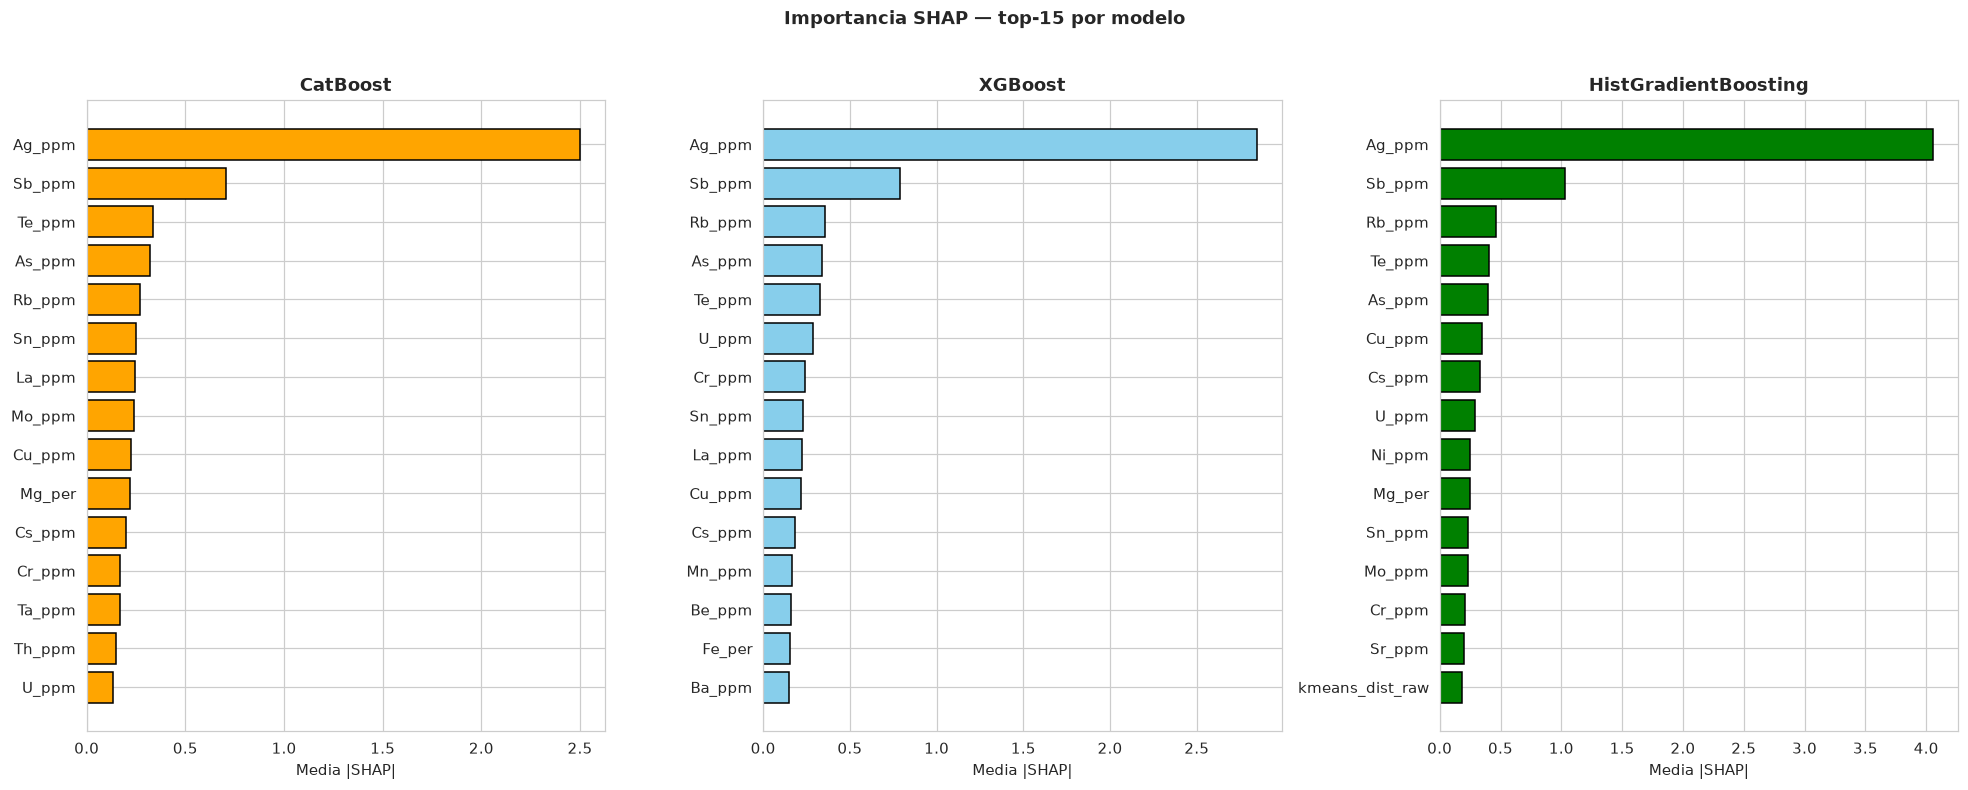

In [9]:
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 7), sharey=False)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    r = shap_results[m]
    top15 = r['imp_df'].head(15)
    ax.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1], color=color, edgecolor='black')
    ax.set_xlabel('Media |SHAP|')
    ax.set_title(f'{m}', fontweight='bold')
plt.suptitle('Importancia SHAP — top-15 por modelo', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/shap_bar_comparacion.png', bbox_inches='tight'); plt.show()

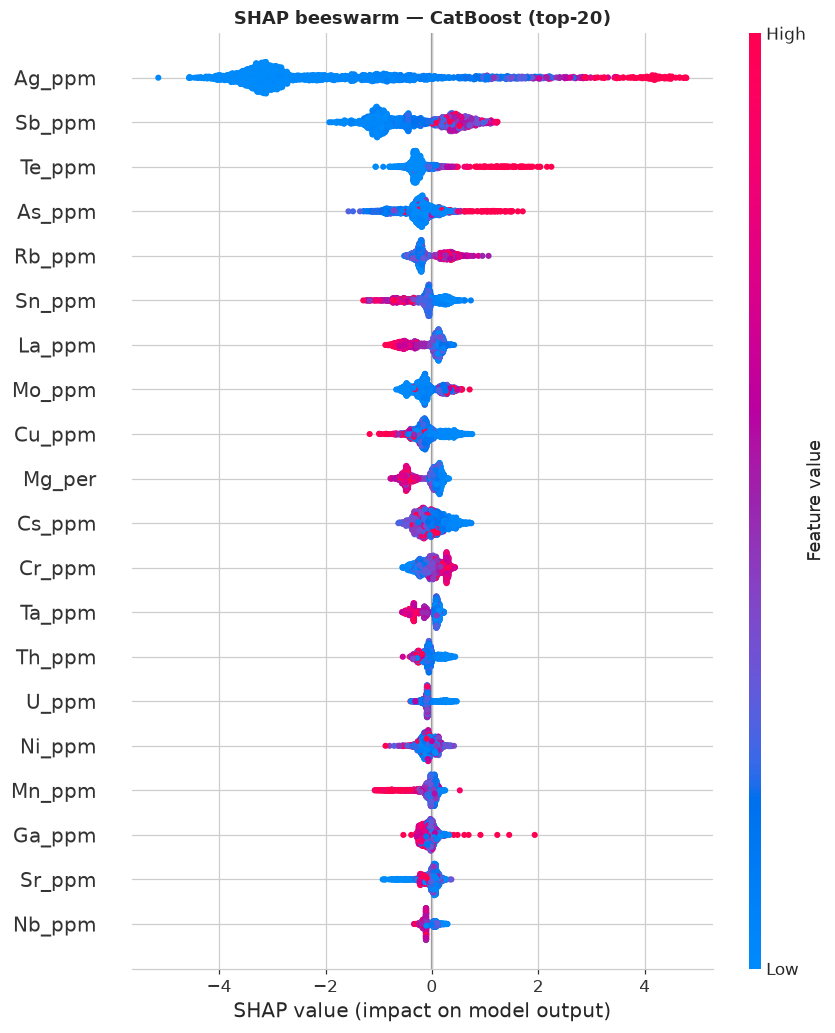

In [10]:
# Beeswarm del modelo con mayor F1_CV en S2 (primer top-3)
m0 = TOP_3[0]
r0 = shap_results[m0]
plt.figure(figsize=(10, 8))
shap.summary_plot(r0['sv'], r0['Xtr'], max_display=20, show=False)
plt.title(f'SHAP beeswarm — {m0} (top-20)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/shap_beeswarm.png', bbox_inches='tight'); plt.show()

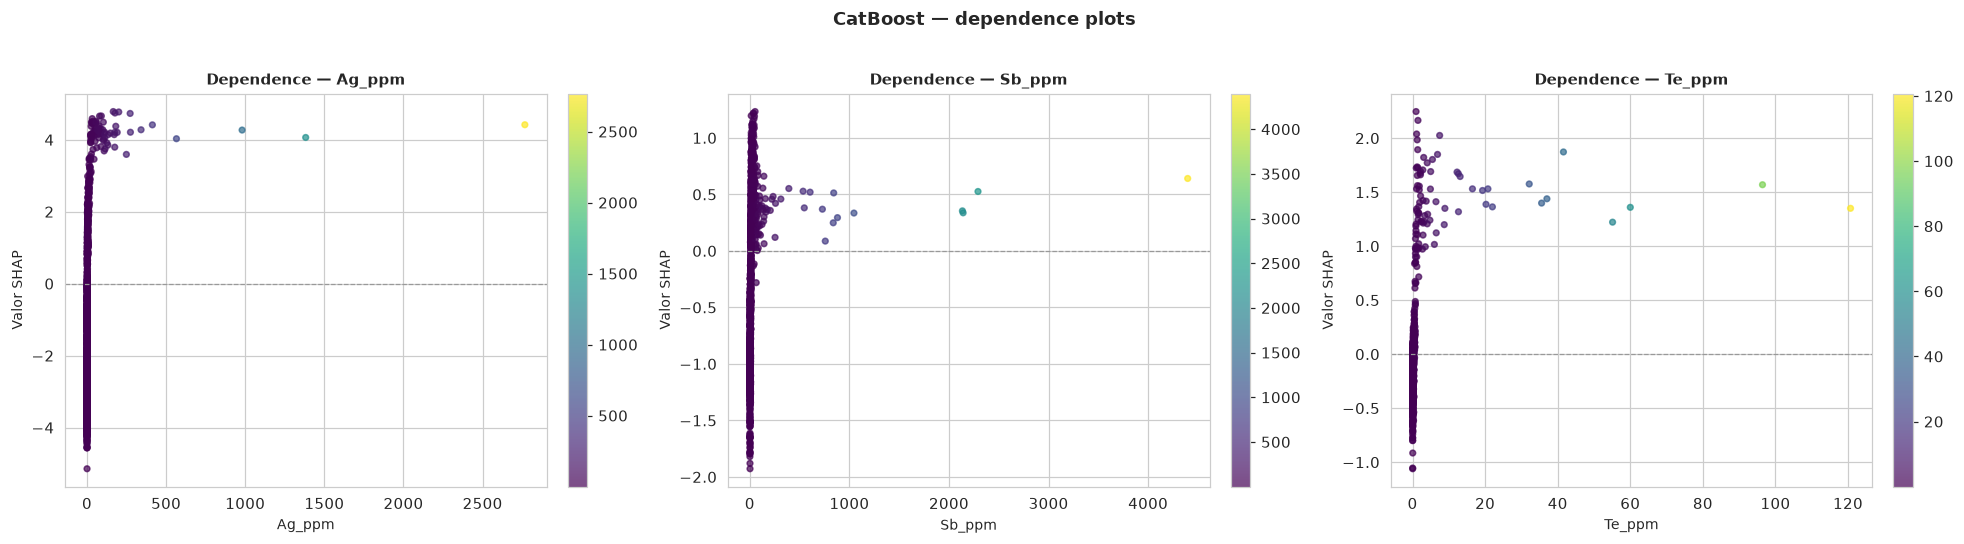

In [11]:
# Dependence plots de las 3 features más importantes del modelo líder
top3_feats = r0['imp_ser'].index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for i, feat in enumerate(top3_feats):
    j = r0['feats'].index(feat)
    xvals = r0['Xtr'][feat].values
    yvals = r0['sv'][:, j]
    sc = axes[i].scatter(xvals, yvals, c=xvals, cmap='viridis', s=14, alpha=0.7)
    axes[i].axhline(0, color='0.6', lw=0.8, ls='--')
    axes[i].set_xlabel(feat, fontsize=9); axes[i].set_ylabel('Valor SHAP', fontsize=9)
    axes[i].set_title(f'Dependence — {feat}', fontweight='bold', fontsize=10)
    fig.colorbar(sc, ax=axes[i], fraction=0.046, pad=0.04)
plt.suptitle(f'{m0} — dependence plots', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/shap_dependence_top3.png', bbox_inches='tight'); plt.show()

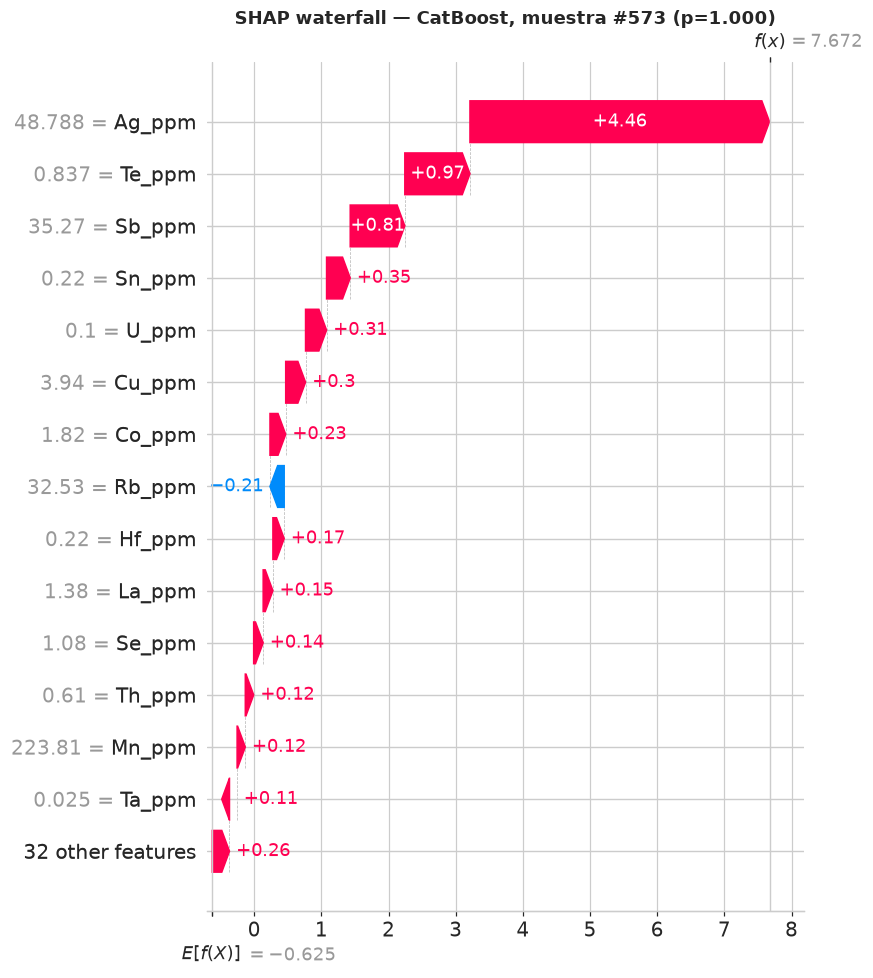

In [12]:
# Waterfall de un ejemplo positivo bien puntuado
proba_tr = r0['clf'].predict_proba(r0['Xtr'])[:, 1]
mask_pos = (y_train.values == 1)
idx_ej = int(np.where(mask_pos)[0][np.argmax(proba_tr[mask_pos])])
expl = shap.Explanation(values=r0['sv'][idx_ej], base_values=r0['base_val'],
                        data=r0['Xtr'].iloc[idx_ej].values, feature_names=r0['feats'])
plt.figure()
shap.plots.waterfall(expl, max_display=15, show=False)
plt.title(f'SHAP waterfall — {m0}, muestra #{idx_ej} (p={proba_tr[idx_ej]:.3f})', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/shap_waterfall.png', bbox_inches='tight'); plt.show()

## Selección de features (regla 1-SE)

Para cada modelo del top-3 se realiza:
1. Acumulación del |SHAP| hasta el 95% → se obtiene un universo candidato.
2. Barrido CV (top-1, top-2, ..., top-n) sobre ese universo.
3. **Regla 1-SE**: se elige el subconjunto más parsimonioso cuyo F1_CV esté dentro de 1 error estándar del máximo.

La regla 1-SE favorece modelos más simples que generalizan mejor, reduciendo el riesgo de sobreajuste a features ruidosas.

In [13]:
sel_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    r = shap_results[m]
    Xtr_m = SETS_TR[cfg['set']]

    # Universo: features que acumulan 95% del |SHAP|
    n_95 = int(np.searchsorted(r['imp_df']['cum_frac'].values, 0.95) + 1)
    n_95 = min(n_95, len(r['feats']))
    feats_95 = r['imp_df']['feature'].iloc[:n_95].tolist()

    # Barrido CV
    t0 = time.time()
    rows = []
    for k in range(1, n_95 + 1):
        mu, sd = f1_cv(m, Xtr_m[feats_95[:k]], y_train, cfg['params'], cfg['balanceo'])
        rows.append({'n_features': k, 'f1_cv_mean': mu, 'f1_cv_std': sd})
    sweep = pd.DataFrame(rows)
    elapsed = time.time() - t0

    # Regla 1-SE
    k_best = int(sweep['f1_cv_mean'].idxmax())
    f1_best = float(sweep['f1_cv_mean'].iloc[k_best])
    se_best = float(sweep['f1_cv_std'].iloc[k_best]) / np.sqrt(5)
    umbral_1se = f1_best - se_best
    elegibles = sweep[sweep['f1_cv_mean'] >= umbral_1se]
    n_opt = int(elegibles['n_features'].min())
    set_s3 = feats_95[:n_opt]
    f1_sel = float(sweep.loc[sweep['n_features'] == n_opt, 'f1_cv_mean'].iloc[0])

    sel_results[m] = {
        'n_95': n_95, 'n_opt': n_opt, 'set_s3': set_s3,
        'f1_sel': f1_sel, 'f1_best': f1_best, 'se_best': se_best,
        'umbral_1se': umbral_1se, 'sweep': sweep,
    }
    sweep.to_csv(f'{DIR_TAB}/seleccion_1se_{m.lower().replace(" ", "_")}.csv', index=False)
    print(f'{m}: 95%|SHAP|={n_95} → 1-SE={n_opt} features → F1_CV={f1_sel:.4f} '
          f'(mejor={f1_best:.4f} con {sweep["n_features"].iloc[k_best]}) [{elapsed:.0f}s]')

CatBoost: 95%|SHAP|=36 → 1-SE=21 features → F1_CV=0.7406 (mejor=0.7563 con 29) [119s]
XGBoost: 95%|SHAP|=35 → 1-SE=11 features → F1_CV=0.7237 (mejor=0.7386 con 32) [35s]
HistGradientBoosting: 95%|SHAP|=37 → 1-SE=11 features → F1_CV=0.7244 (mejor=0.7434 con 25) [58s]


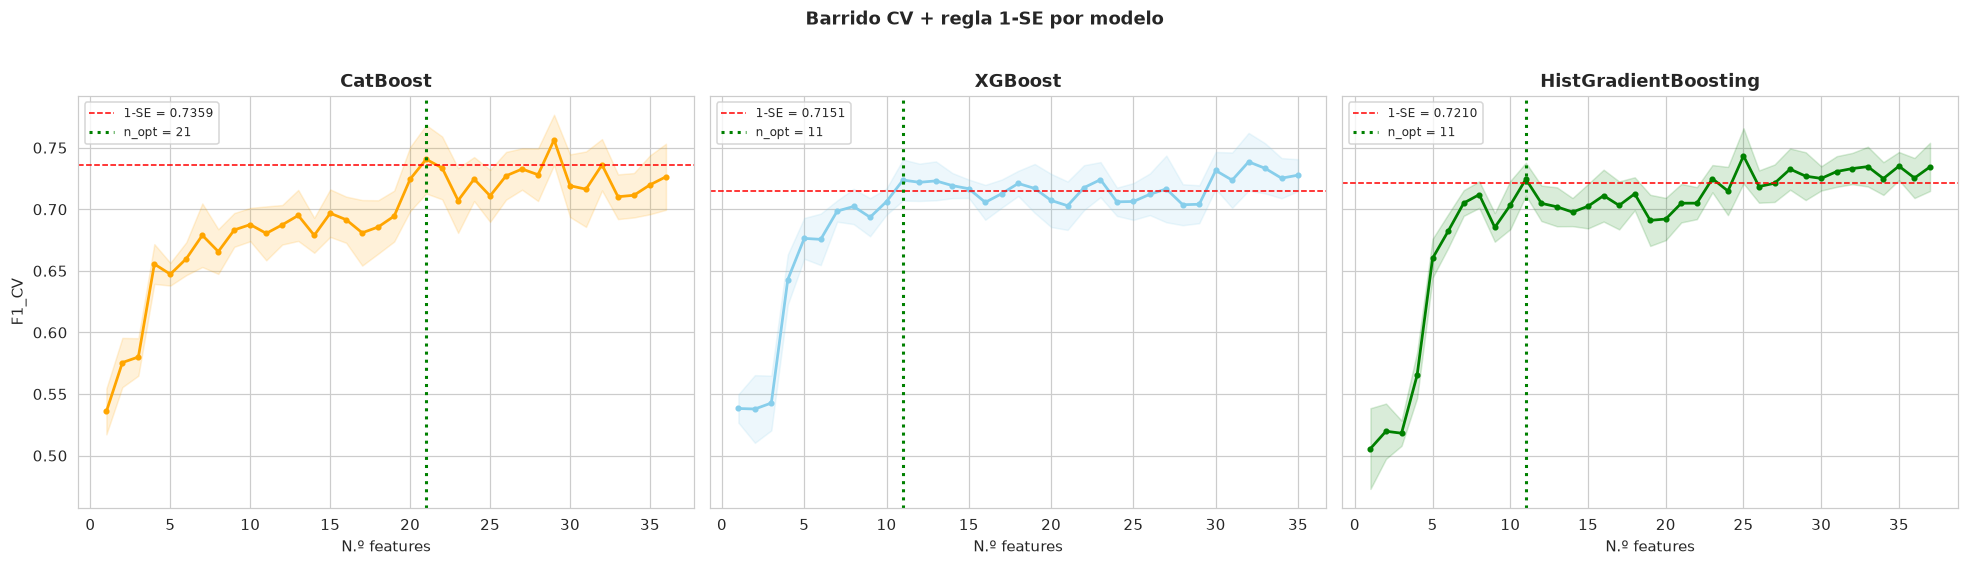

In [14]:
# Gráfico del barrido 1-SE para cada modelo
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    sr = sel_results[m]
    sw = sr['sweep']
    ax.plot(sw['n_features'], sw['f1_cv_mean'], color=color, lw=1.8, marker='o', markersize=3)
    ax.fill_between(sw['n_features'],
                    sw['f1_cv_mean'] - sw['f1_cv_std']/np.sqrt(5),
                    sw['f1_cv_mean'] + sw['f1_cv_std']/np.sqrt(5),
                    color=color, alpha=0.15)
    ax.axhline(sr['umbral_1se'], ls='--', color='red', lw=1, label=f'1-SE = {sr["umbral_1se"]:.4f}')
    ax.axvline(sr['n_opt'], ls=':', color='green', lw=2, label=f'n_opt = {sr["n_opt"]}')
    ax.set_xlabel('N.º features'); ax.set_title(f'{m}', fontweight='bold')
    ax.legend(fontsize=8)
axes[0].set_ylabel('F1_CV')
plt.suptitle('Barrido CV + regla 1-SE por modelo', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/seleccion_1se.png', bbox_inches='tight'); plt.show()

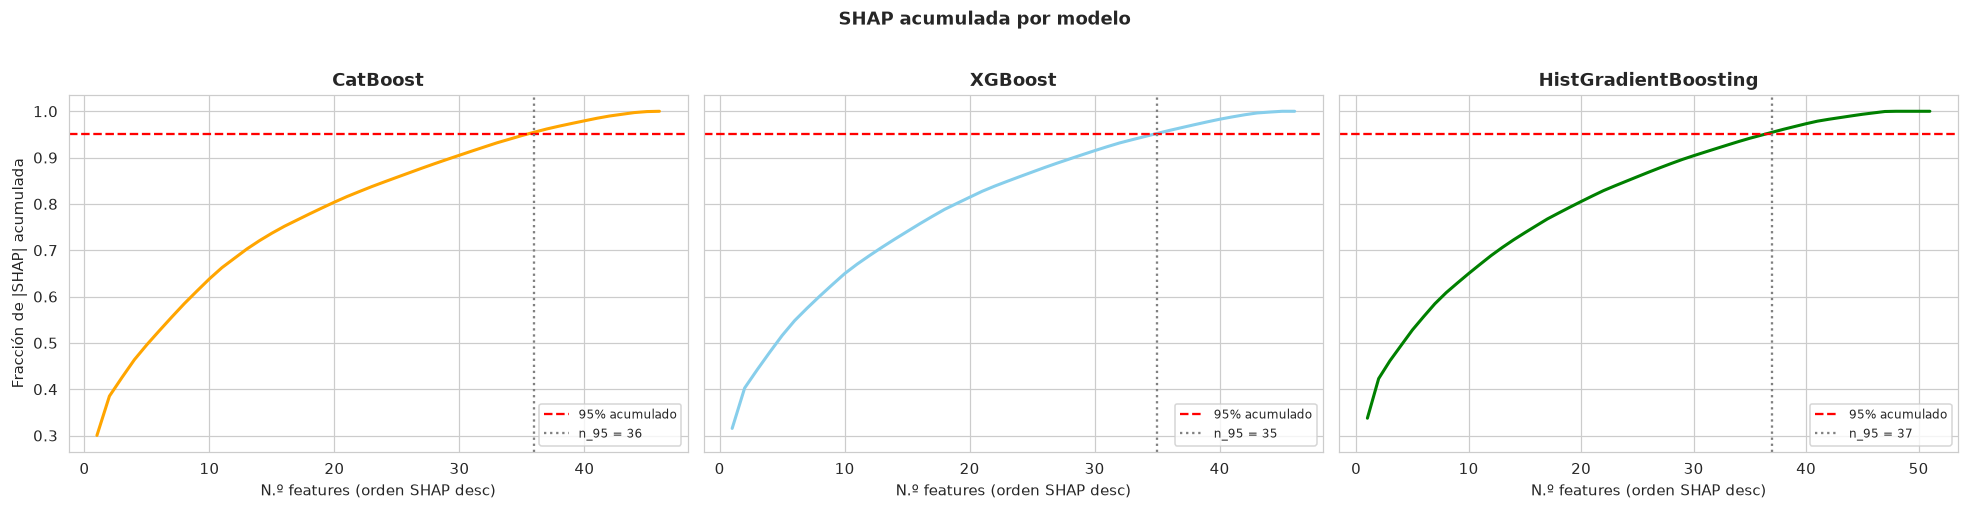

In [15]:
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 4.5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    r = shap_results[m]
    sr = sel_results[m]
    ax.plot(range(1, len(r['imp_df'])+1), r['imp_df']['cum_frac'].values, color=color, lw=2)
    ax.axhline(0.95, ls='--', color='red', label='95% acumulado')
    ax.axvline(sr['n_95'], ls=':', color='gray', label=f'n_95 = {sr["n_95"]}')
    ax.set_xlabel('N.º features (orden SHAP desc)'); ax.set_title(f'{m}', fontweight='bold')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Fracción de |SHAP| acumulada')
plt.suptitle('SHAP acumulada por modelo', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/shap_acumulada.png', bbox_inches='tight'); plt.show()

## Re-Optuna sobre features seleccionadas

Se re-optimizan los hiperparámetros de cada modelo sobre su set reducido (1-SE). El espacio de búsqueda incluye **parámetros de regularización** para controlar el sobreajuste:

- **CatBoost:** `l2_leaf_reg`, `depth` acotado.
- **XGBoost:** `reg_lambda`, `reg_alpha`, `min_child_weight`, `subsample`.
- **HistGradientBoosting:** `l2_regularization`, `min_samples_leaf` elevado, `max_leaf_nodes` acotado.

Se ejecutan 100 trials por modelo con `TPESampler(seed=SEED)`.

In [16]:
def espacio_optuna_s3(mod, trial):
    """Espacio de búsqueda regularizado para el re-Optuna del Sprint 3."""
    if mod == 'CatBoost':
        return {
            'iterations': trial.suggest_int('iterations', 50, 300),
            'depth': trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        }
    if mod == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        }
    if mod == 'HistGradientBoosting':
        return {
            'max_iter': trial.suggest_int('max_iter', 50, 300),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 40),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 80),
            'l2_regularization': trial.suggest_float('l2_regularization', 0.5, 5.0),
        }
    raise ValueError(mod)

N_TRIALS_S3 = 100
optuna_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr = sel_results[m]
    Xtr_sel = SETS_TR[cfg['set']][sr['set_s3']]

    def objective(trial, mod=m, Xtr=Xtr_sel, bal=cfg['balanceo']):
        params = espacio_optuna_s3(mod, trial)
        mu, _ = f1_cv(mod, Xtr, y_train, params, bal)
        return mu

    print(f'{m}: Re-Optuna {N_TRIALS_S3} trials sobre {len(sr["set_s3"])} features ...')
    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS_S3, n_jobs=1, show_progress_bar=False)
    elapsed = time.time() - t0

    f1_opt = float(study.best_value)
    if f1_opt >= sr['f1_sel']:
        params_s3 = dict(study.best_params)
        f1_s3 = f1_opt; origen = 'Optuna S3'
    else:
        params_s3 = dict(cfg['params'])
        f1_s3 = sr['f1_sel']; origen = 'Params S2 (Optuna no mejoró)'

    optuna_results[m] = {
        'study': study, 'f1_optuna': f1_opt, 'f1_fijos': sr['f1_sel'],
        'params_s3': params_s3, 'f1_s3': f1_s3, 'origen': origen, 'elapsed': elapsed,
    }
    print(f'  F1_CV Optuna={f1_opt:.4f} vs Fijos={sr["f1_sel"]:.4f} → {origen} [{elapsed:.0f}s]')
    print(f'  Params: {params_s3}')

CatBoost: Re-Optuna 100 trials sobre 21 features ...
  F1_CV Optuna=0.7447 vs Fijos=0.7406 → Optuna S3 [596s]
  Params: {'iterations': 162, 'depth': 5, 'learning_rate': 0.13615825447488727, 'l2_leaf_reg': 3.2670566091196096, 'subsample': 0.6212393136181309}
XGBoost: Re-Optuna 100 trials sobre 11 features ...
  F1_CV Optuna=0.7363 vs Fijos=0.7237 → Optuna S3 [77s]
  Params: {'n_estimators': 208, 'max_depth': 6, 'learning_rate': 0.19695333046532648, 'subsample': 0.6327402386332946, 'colsample_bytree': 0.5349734253816496, 'reg_lambda': 3.23348125927181, 'reg_alpha': 1.3045150798100684, 'min_child_weight': 6}
HistGradientBoosting: Re-Optuna 100 trials sobre 11 features ...
  F1_CV Optuna=0.7289 vs Fijos=0.7244 → Optuna S3 [154s]
  Params: {'max_iter': 299, 'max_leaf_nodes': 20, 'learning_rate': 0.1574160343892239, 'min_samples_leaf': 48, 'l2_regularization': 2.502742707600918}


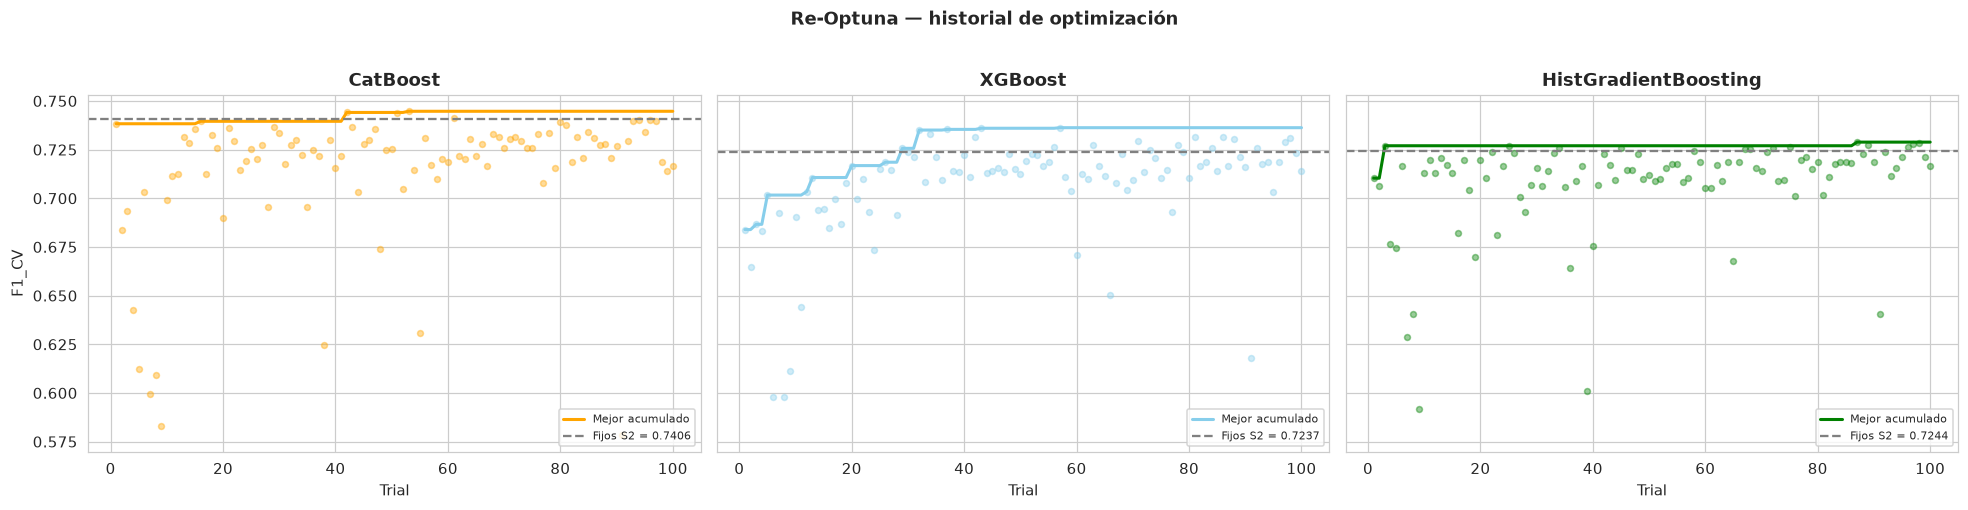

In [17]:
# Historial de optimización por modelo
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 4.5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    opr = optuna_results[m]
    vals = [t.value for t in opr['study'].trials if t.value is not None]
    best_run = np.maximum.accumulate(vals)
    ax.scatter(range(1, len(vals)+1), vals, s=15, alpha=0.4, color=color)
    ax.plot(range(1, len(vals)+1), best_run, lw=2, color=color, label='Mejor acumulado')
    ax.axhline(sel_results[m]['f1_sel'], ls='--', color='gray', label=f'Fijos S2 = {sel_results[m]["f1_sel"]:.4f}')
    ax.set_xlabel('Trial'); ax.set_title(f'{m}', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
axes[0].set_ylabel('F1_CV')
plt.suptitle('Re-Optuna — historial de optimización', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/optuna_s3_history.png', bbox_inches='tight'); plt.show()

In [18]:
optuna_params_export = {}
for m in TOP_3:
    opr = optuna_results[m]
    optuna_params_export[m] = {
        'f1_cv_optuna': round(opr['f1_optuna'], 4),
        'f1_cv_fijos_s2': round(opr['f1_fijos'], 4),
        'params_elegidos': opr['params_s3'],
        'origen': opr['origen'],
    }
with open(f'{DIR_TAB}/optuna_s3_params.json', 'w') as f:
    json.dump(optuna_params_export, f, indent=2, ensure_ascii=False)
print('Params de Optuna S3 guardados.')

Params de Optuna S3 guardados.


## Curvas de aprendizaje (diagnóstico de sesgo/varianza)

Se comparan las curvas de aprendizaje **antes** (params S2) y **después** (params S3) de la re-optimización, para cada modelo sobre su set 1-SE. La brecha train-validación (gap) cuantifica el grado de sobreajuste.

In [19]:
train_sizes_frac = np.linspace(0.1, 1.0, 8)
lc_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr = sel_results[m]
    opr = optuna_results[m]
    Xtr_sel = SETS_TR[cfg['set']][sr['set_s3']]

    # Pre (params S2)
    sizes_pre, tr_pre, va_pre = learning_curve(
        make_pipe(m, cfg['params'], cfg['balanceo']), Xtr_sel, y_train,
        cv=CV5, scoring='f1', train_sizes=train_sizes_frac, n_jobs=-1,
        shuffle=True, random_state=SEED)
    gap_pre = float((tr_pre.mean(1) - va_pre.mean(1))[-1])

    # Post (params S3)
    sizes_post, tr_post, va_post = learning_curve(
        make_pipe(m, opr['params_s3'], cfg['balanceo']), Xtr_sel, y_train,
        cv=CV5, scoring='f1', train_sizes=train_sizes_frac, n_jobs=-1,
        shuffle=True, random_state=SEED)
    gap_post = float((tr_post.mean(1) - va_post.mean(1))[-1])

    lc_results[m] = {
        'sizes_pre': sizes_pre, 'tr_pre': tr_pre, 'va_pre': va_pre, 'gap_pre': gap_pre,
        'sizes_post': sizes_post, 'tr_post': tr_post, 'va_post': va_post, 'gap_post': gap_post,
    }
    gap_df = pd.DataFrame({
        'train_size': sizes_post.astype(int),
        'f1_train_pre': tr_pre.mean(1).round(4), 'f1_val_pre': va_pre.mean(1).round(4),
        'gap_pre': (tr_pre.mean(1) - va_pre.mean(1)).round(4),
        'f1_train_post': tr_post.mean(1).round(4), 'f1_val_post': va_post.mean(1).round(4),
        'gap_post': (tr_post.mean(1) - va_post.mean(1)).round(4),
    })
    gap_df.to_csv(f'{DIR_TAB}/learning_curves_{m.lower().replace(" ", "_")}.csv', index=False)
    print(f'{m}: gap pre={gap_pre:.4f} → post={gap_post:.4f} (Δ={gap_post-gap_pre:+.4f})')

CatBoost: gap pre=0.2644 → post=0.2721 (Δ=+0.0076)
XGBoost: gap pre=0.2860 → post=0.2495 (Δ=-0.0365)
HistGradientBoosting: gap pre=0.2791 → post=0.2741 (Δ=-0.0050)


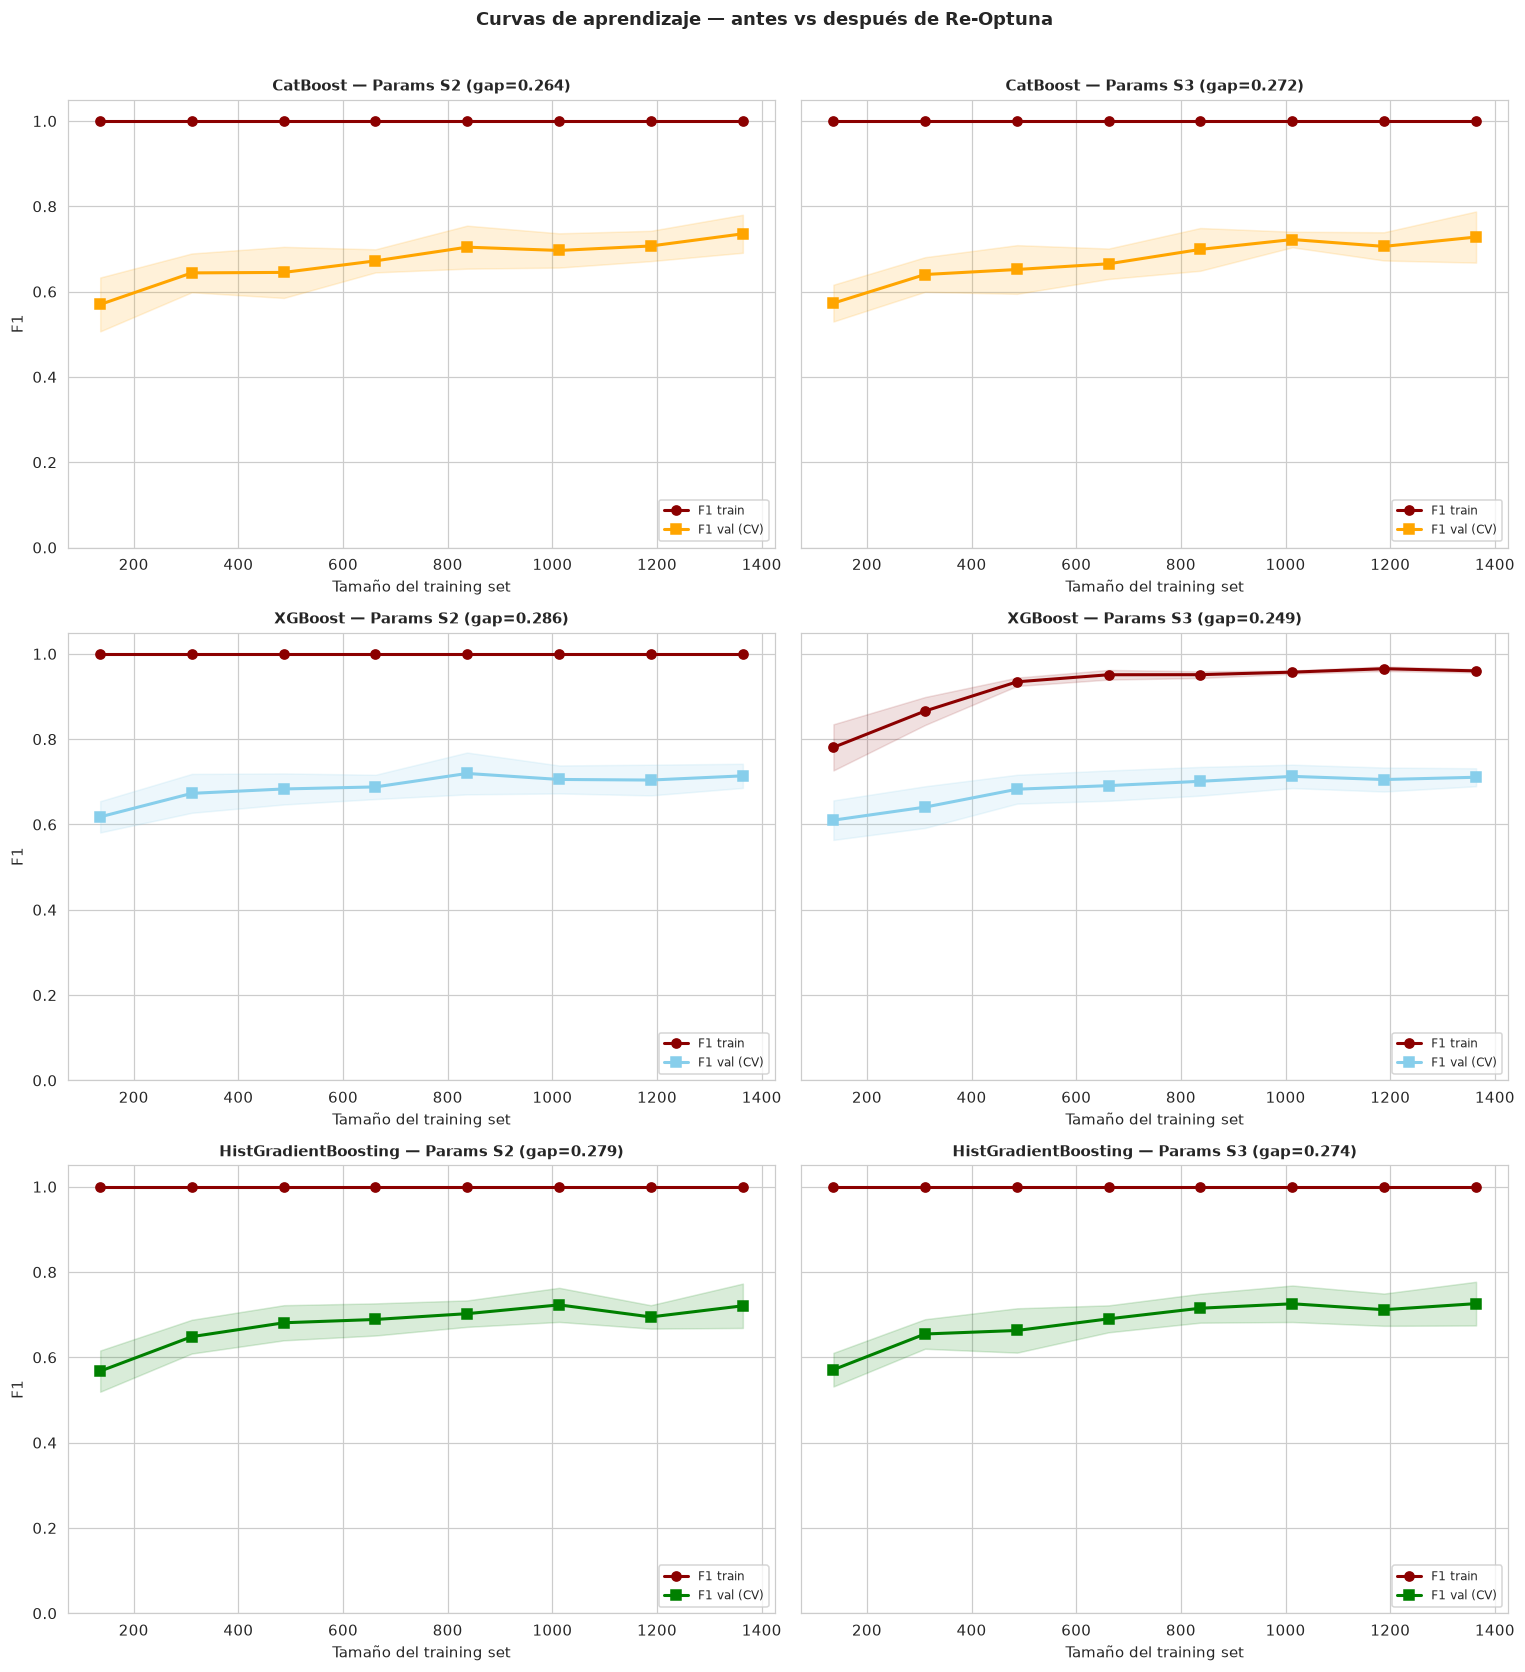

In [20]:
fig, axes = plt.subplots(len(TOP_3), 2, figsize=(14, 5*len(TOP_3)), sharey=True)
colores = ['orange', 'skyblue', 'green']
for row, (m, color) in enumerate(zip(TOP_3, colores)):
    lc = lc_results[m]
    for col, (sizes, tr, va, gap, tit) in enumerate([
        (lc['sizes_pre'], lc['tr_pre'], lc['va_pre'], lc['gap_pre'], f'Params S2 (gap={lc["gap_pre"]:.3f})'),
        (lc['sizes_post'], lc['tr_post'], lc['va_post'], lc['gap_post'], f'Params S3 (gap={lc["gap_post"]:.3f})'),
    ]):
        ax = axes[row, col]
        trm, trs = tr.mean(1), tr.std(1)
        vam, vas = va.mean(1), va.std(1)
        ax.plot(sizes, trm, marker='o', color='darkred', lw=2, label='F1 train')
        ax.fill_between(sizes, trm-trs, trm+trs, color='darkred', alpha=0.12)
        ax.plot(sizes, vam, marker='s', color=color, lw=2, label='F1 val (CV)')
        ax.fill_between(sizes, vam-vas, vam+vas, color=color, alpha=0.15)
        ax.set_xlabel('Tamaño del training set'); ax.set_ylim(0, 1.05)
        ax.set_title(f'{m} — {tit}', fontweight='bold', fontsize=10)
        ax.legend(fontsize=8, loc='lower right')
    axes[row, 0].set_ylabel('F1')
plt.suptitle('Curvas de aprendizaje — antes vs después de Re-Optuna', fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/learning_curves_s3_comparacion.png', bbox_inches='tight'); plt.show()

## Calibración y ajuste de umbral

Para cada modelo del top-3 se calculan probabilidades **OOF** (out-of-fold) con tres variantes:
- Sin calibrar
- Sigmoide (Platt scaling)
- Isotónica

Se elige el método de calibración con menor Brier score OOF. Luego se ajusta el **umbral de decisión** sobre las probabilidades OOF calibradas, maximizando F1.

> **Nota:** F1_OOF y F1_CV son métricas distintas. F1_CV es la media de los F1 por fold; F1_OOF aplica un umbral único a las probabilidades concatenadas de todos los folds. Es esperable que difieran, y se documentan ambas sin forzar coherencia.

In [21]:
def oof_proba(factory, X, yv):
    """Probabilidades OOF: entrena en cada fold de train, predice el fold de validación."""
    oof = np.zeros(len(yv), dtype=float)
    for tr_idx, va_idx in CV5.split(X, yv):
        est = factory()
        est.fit(X.iloc[tr_idx], yv.iloc[tr_idx])
        oof[va_idx] = est.predict_proba(X.iloc[va_idx])[:, 1]
    return oof

cal_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr = sel_results[m]
    opr = optuna_results[m]
    Xtr_sel = SETS_TR[cfg['set']][sr['set_s3']]

    fac_uncal = lambda m_=m, p_=opr['params_s3'], b_=cfg['balanceo']: make_pipe(m_, p_, b_)
    fac_sig   = lambda m_=m, p_=opr['params_s3'], b_=cfg['balanceo']: CalibratedClassifierCV(
                    make_pipe(m_, p_, b_), method='sigmoid', cv=3)
    fac_iso   = lambda m_=m, p_=opr['params_s3'], b_=cfg['balanceo']: CalibratedClassifierCV(
                    make_pipe(m_, p_, b_), method='isotonic', cv=3)

    oof_uncal = oof_proba(fac_uncal, Xtr_sel, y_train)
    oof_sig   = oof_proba(fac_sig,   Xtr_sel, y_train)
    oof_iso   = oof_proba(fac_iso,   Xtr_sel, y_train)

    brier = {'sin_calibrar': brier_score_loss(y_train, oof_uncal),
             'sigmoid':      brier_score_loss(y_train, oof_sig),
             'isotonic':     brier_score_loss(y_train, oof_iso)}

    if brier['isotonic'] < brier['sigmoid']:
        metodo_cal, oof_cal = 'isotonic', oof_iso
    else:
        metodo_cal, oof_cal = 'sigmoid', oof_sig

    # Umbral óptimo por F1 sobre OOF calibrado
    prec, rec, thr = precision_recall_curve(y_train, oof_cal)
    f1_grid = 2 * prec * rec / (prec + rec + 1e-12)
    best_i = int(np.nanargmax(f1_grid[:-1]))
    umbral = float(thr[best_i])
    f1_oof = float(f1_grid[best_i])

    cal_results[m] = {
        'oof_uncal': oof_uncal, 'oof_sig': oof_sig, 'oof_iso': oof_iso, 'oof_cal': oof_cal,
        'brier': brier, 'metodo_cal': metodo_cal, 'umbral': umbral, 'f1_oof': f1_oof,
    }
    print(f'{m}: cal={metodo_cal} | Brier={brier[metodo_cal]:.5f} | umbral={umbral:.4f} | F1_OOF={f1_oof:.4f}')

CatBoost: cal=isotonic | Brier=0.04862 | umbral=0.3536 | F1_OOF=0.7182
XGBoost: cal=isotonic | Brier=0.05035 | umbral=0.3225 | F1_OOF=0.7226
HistGradientBoosting: cal=isotonic | Brier=0.04944 | umbral=0.4308 | F1_OOF=0.7221


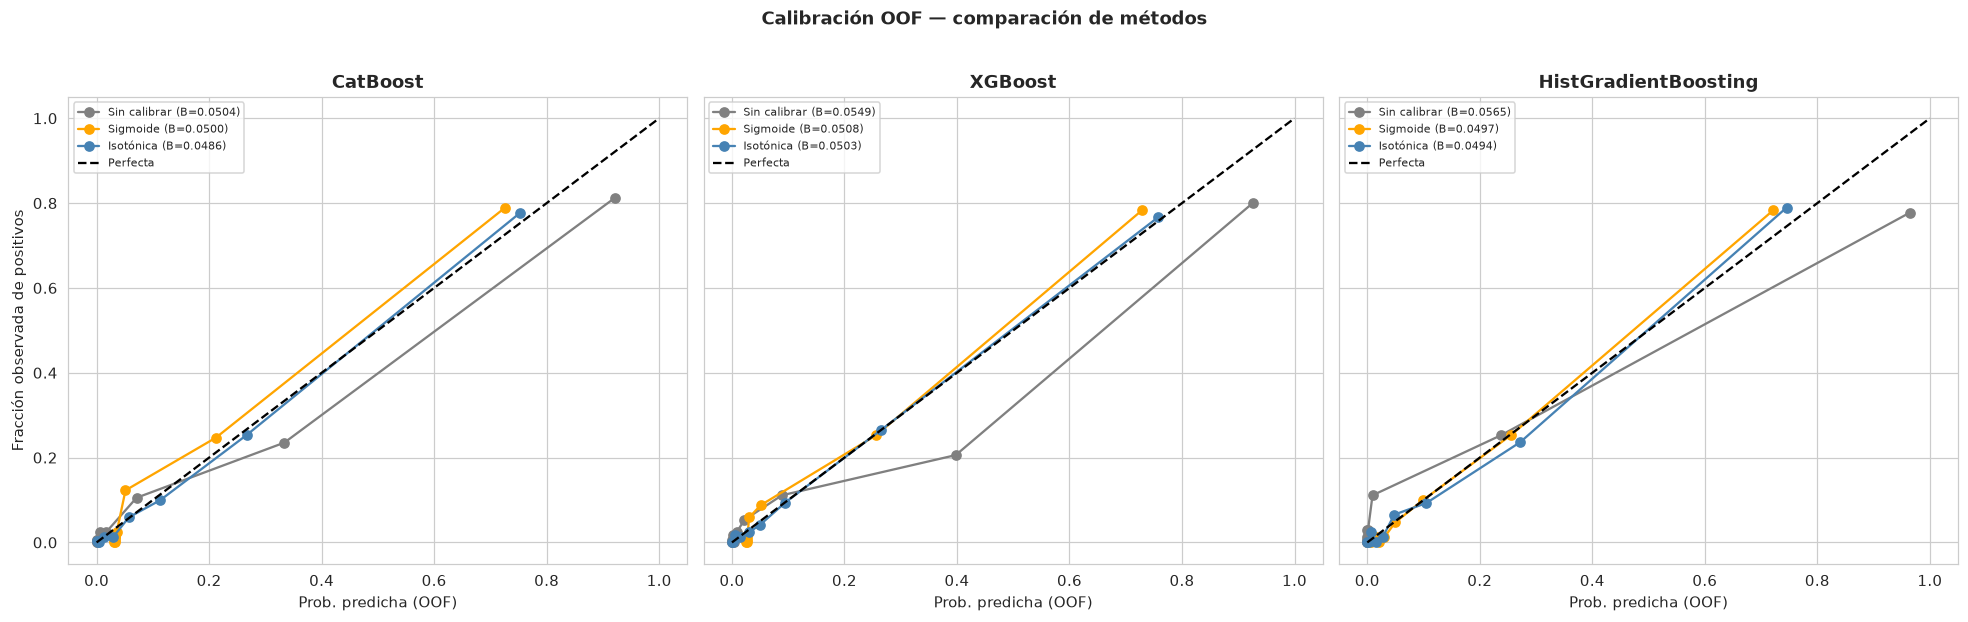

In [22]:
# Curvas de calibración (reliability)
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 5.5), sharey=True)
for ax, m in zip(axes, TOP_3):
    cr = cal_results[m]
    for probs, nombre, col in [(cr['oof_uncal'], 'Sin calibrar', 'gray'),
                               (cr['oof_sig'], 'Sigmoide', 'orange'),
                               (cr['oof_iso'], 'Isotónica', 'steelblue')]:
        fx, fy = calibration_curve(y_train, probs, n_bins=10, strategy='quantile')
        ax.plot(fy, fx, marker='o', lw=1.5, color=col,
                label=f'{nombre} (B={brier_score_loss(y_train, probs):.4f})')
    ax.plot([0, 1], [0, 1], '--', color='black', label='Perfecta')
    ax.set_xlabel('Prob. predicha (OOF)'); ax.set_title(f'{m}', fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
axes[0].set_ylabel('Fracción observada de positivos')
plt.suptitle('Calibración OOF — comparación de métodos', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/calibracion.png', bbox_inches='tight'); plt.show()

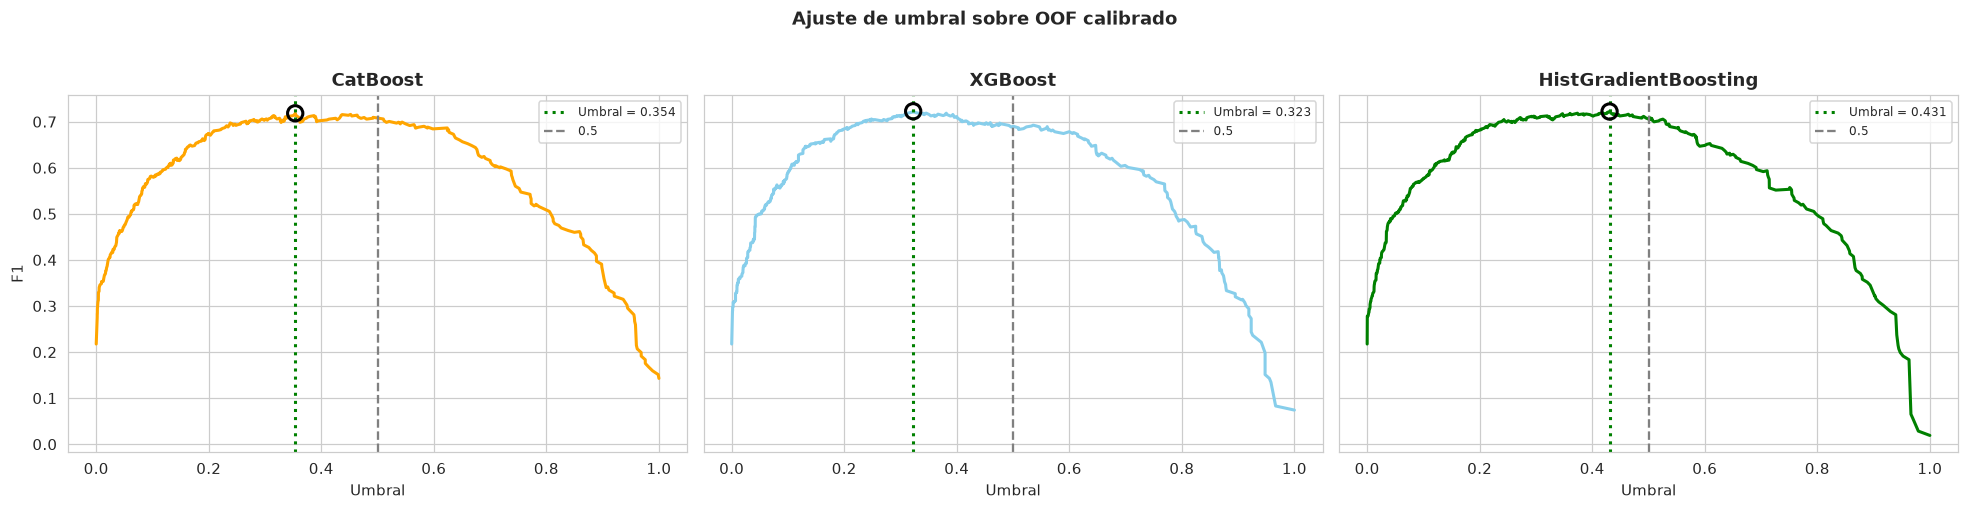

In [23]:
# Ajuste de umbral (F1 vs umbral OOF calibrado)
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 4.5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    cr = cal_results[m]
    prec, rec, thr = precision_recall_curve(y_train, cr['oof_cal'])
    f1g = 2 * prec * rec / (prec + rec + 1e-12)
    ax.plot(thr, f1g[:-1], color=color, lw=2)
    ax.axvline(cr['umbral'], ls=':', color='green', lw=2, label=f'Umbral = {cr["umbral"]:.3f}')
    ax.axvline(0.5, ls='--', color='gray', label='0.5')
    ax.scatter([cr['umbral']], [cr['f1_oof']], s=100, facecolors='none',
               edgecolors='black', linewidths=2, zorder=5)
    ax.set_xlabel('Umbral'); ax.set_title(f'{m}', fontweight='bold')
    ax.legend(fontsize=8)
axes[0].set_ylabel('F1')
plt.suptitle('Ajuste de umbral sobre OOF calibrado', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/ajuste_umbral.png', bbox_inches='tight'); plt.show()

## Selección del campeón

Se comparan los tres modelos tras el pipeline completo (1-SE + Re-Optuna + calibración + umbral) y se elige el de **mayor F1_CV** como campeón del Sprint 3.

In [24]:
resumen_top3 = []
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr = sel_results[m]
    opr = optuna_results[m]
    cr = cal_results[m]
    resumen_top3.append({
        'Modelo': m,
        'Set S2': cfg['set'],
        'Features S2': len(SETS_TR[cfg['set']].columns),
        'Features S3 (1-SE)': sr['n_opt'],
        'F1_CV S2': cfg['f1_cv'],
        'F1_CV S3 (re-Optuna)': opr['f1_s3'],
        'Calibración': cr['metodo_cal'],
        'Umbral': cr['umbral'],
        'F1_OOF': cr['f1_oof'],
        'Gap pre': lc_results[m]['gap_pre'],
        'Gap post': lc_results[m]['gap_post'],
    })

df_resumen = pd.DataFrame(resumen_top3)
df_resumen.to_csv(f'{DIR_TAB}/comparativa_top3_s3.csv', index=False)

# Selección del campeón por F1_CV
f1_cv_dict = {m: optuna_results[m]['f1_s3'] for m in TOP_3}
CAMPEON = max(f1_cv_dict, key=f1_cv_dict.get)
F1_CAMPEON = f1_cv_dict[CAMPEON]

print(coral(f'\nCampeón del Sprint 3: {CAMPEON} (F1_CV = {F1_CAMPEON:.4f})'))
print(f'\nComparativa completa:')

def resaltar_maximo(s):
    is_max = s == s.max()
    return ['background-color: coral; color: white; font-weight: bold' if v else '' for v in is_max]

display(df_resumen.style.apply(resaltar_maximo,
    subset=['F1_CV S3 (re-Optuna)', 'F1_OOF']))


Campeón del Sprint 3: CatBoost (F1_CV = 0.7447)

Comparativa completa:


,Modelo,Set S2,Features S2,Features S3 (1-SE),F1_CV S2,F1_CV S3 (re-Optuna),Calibración,Umbral,F1_OOF,Gap pre,Gap post
0,CatBoost,E0 Base,46,21,0.749300,0.744702,isotonic,0.353632,0.718204,0.264431,0.272080
1,XGBoost,E0 Base,46,11,0.744000,0.736271,isotonic,0.322524,0.722611,0.285989,0.249460
2,HistGradientBoosting,E2 +Cluster RAW,51,11,0.742800,0.728860,isotonic,0.430776,0.722078,0.279136,0.274091


## Ablación (contribución de Ag y elementos económicos)

Los elementos económicos (Au, Ag, Cu, Pb, Zn) excluidos del feature engineering en el Sprint 2 permanecen como features base. En particular, **Ag_ppm** suele concentrar una fracción importante del |SHAP| por su asociación natural con Au (pathfinder epitermal). Este experimento cuantifica cuánto cae el F1_CV del campeón al excluirlos, para demostrar que el modelo no depende de un solo proxy.

In [25]:
ECONOMICOS = RESUMEN_S2['elementos_economicos']
campeon_cfg = TOP3_CONFIG[CAMPEON]
campeon_set = sel_results[CAMPEON]['set_s3']
campeon_params = optuna_results[CAMPEON]['params_s3']
Xtr_campeon = SETS_TR[campeon_cfg['set']][campeon_set]

# (a) Sin Ag_ppm
set_sin_ag = [f for f in campeon_set if f != 'Ag_ppm']
f1_sin_ag, sd_sin_ag = f1_cv(CAMPEON, SETS_TR[campeon_cfg['set']][set_sin_ag], y_train,
                              campeon_params, campeon_cfg['balanceo'])

# (b) Sin ningún económico
set_sin_econ = [f for f in campeon_set if f not in ECONOMICOS]
f1_sin_econ, sd_sin_econ = f1_cv(CAMPEON, SETS_TR[campeon_cfg['set']][set_sin_econ], y_train,
                                  campeon_params, campeon_cfg['balanceo'])

# (c) Referencia completa
f1_ref = optuna_results[CAMPEON]['f1_s3']

ablacion = pd.DataFrame([
    {'Variante': 'Completo (set S3)', 'N features': len(campeon_set), 'F1_CV': round(f1_ref, 4)},
    {'Variante': 'Sin Ag_ppm', 'N features': len(set_sin_ag), 'F1_CV': round(f1_sin_ag, 4),
     'Δ F1': round(f1_sin_ag - f1_ref, 4)},
    {'Variante': 'Sin económicos', 'N features': len(set_sin_econ), 'F1_CV': round(f1_sin_econ, 4),
     'Δ F1': round(f1_sin_econ - f1_ref, 4)},
])
ablacion.to_csv(f'{DIR_TAB}/ablacion_economicos.csv', index=False)
print('Ablación de elementos económicos:')
print(ablacion.to_string(index=False))
print(f'\n→ Excluir Ag_ppm: Δ F1 = {f1_sin_ag - f1_ref:+.4f}')
print(f'→ Excluir todos los económicos: Δ F1 = {f1_sin_econ - f1_ref:+.4f}')

Ablación de elementos económicos:
         Variante  N features  F1_CV    Δ F1
Completo (set S3)          21 0.7447     NaN
       Sin Ag_ppm          20 0.6061 -0.1386
   Sin económicos          19 0.6126 -0.1321

→ Excluir Ag_ppm: Δ F1 = -0.1386
→ Excluir todos los económicos: Δ F1 = -0.1321


## Evaluación hold-out (informativo)

Se entrena el pipeline calibrado del campeón sobre **todo** el train y se evalúa contra el hold-out. Esta evaluación es informativa — la decisión de métricas se basa en F1_CV.

In [26]:
campeon_cal = cal_results[CAMPEON]['metodo_cal']
campeon_umbral = cal_results[CAMPEON]['umbral']

modelo_final = CalibratedClassifierCV(
    make_pipe(CAMPEON, campeon_params, campeon_cfg['balanceo']),
    method=campeon_cal, cv=5)
modelo_final.fit(Xtr_campeon, y_train)

# Guardar modelo
joblib.dump(modelo_final, f'{DIR_MODELS}/modelo_campeon_s3.pkl')

# Evaluación hold-out
Xte_campeon = SETS_TE[campeon_cfg['set']][campeon_set]
proba_ho = modelo_final.predict_proba(Xte_campeon)[:, 1]
y_pred_ho = (proba_ho >= campeon_umbral).astype(int)

metr_ho = {
    'F1':        f1_score(y_test, y_pred_ho),
    'Accuracy':  accuracy_score(y_test, y_pred_ho),
    'Precision': precision_score(y_test, y_pred_ho, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_ho),
    'AUC-ROC':   roc_auc_score(y_test, proba_ho),
    'AUC-PR':    average_precision_score(y_test, proba_ho),
    'Brier':     brier_score_loss(y_test, proba_ho),
}
print('Métricas HOLD-OUT (informativas):')
for k, v in metr_ho.items():
    print(f'  {k:10s}: {v:.4f}')

Métricas HOLD-OUT (informativas):
  F1        : 0.7619
  Accuracy  : 0.9415
  Precision : 0.7547
  Recall    : 0.7692
  AUC-ROC   : 0.9546
  AUC-PR    : 0.8163
  Brier     : 0.0453


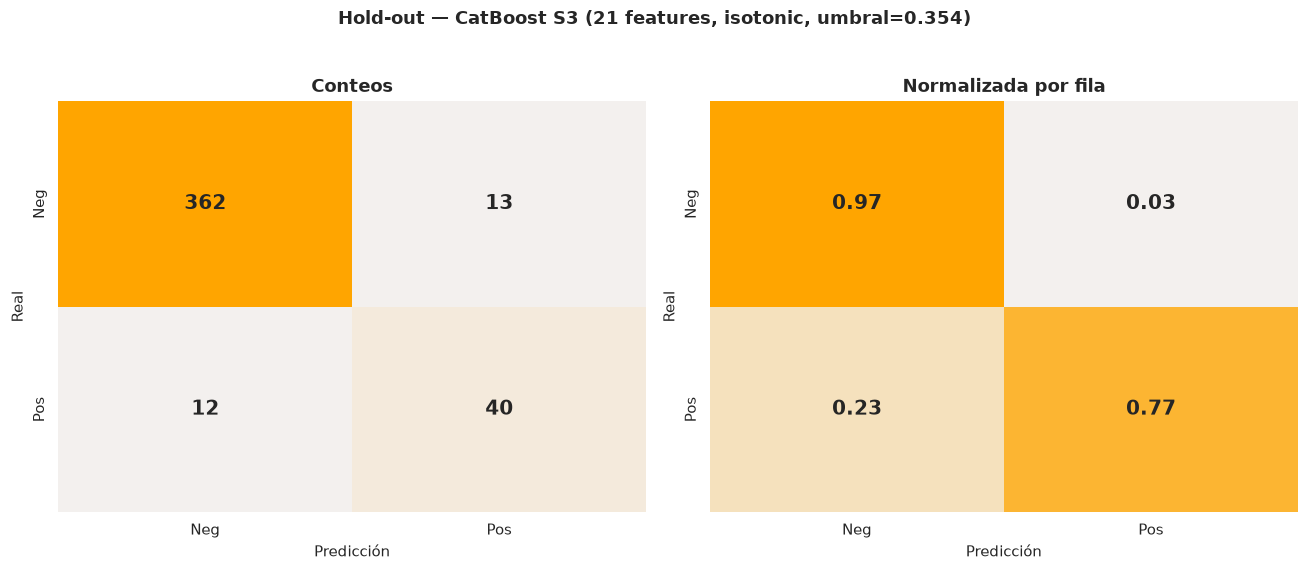

In [27]:
# Matrices de confusión
cm = confusion_matrix(y_test, y_pred_ho)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
color_campeon = 'orange'
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(color_campeon, as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title('Conteos', fontweight='bold'); axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cbar=False, ax=axes[1],
            cmap=sns.light_palette(color_campeon, as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[1].set_title('Normalizada por fila', fontweight='bold'); axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')
plt.suptitle(f'Hold-out — {CAMPEON} S3 ({len(campeon_set)} features, {campeon_cal}, umbral={campeon_umbral:.3f})',
             fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/final_matrices_confusion.png', bbox_inches='tight'); plt.show()

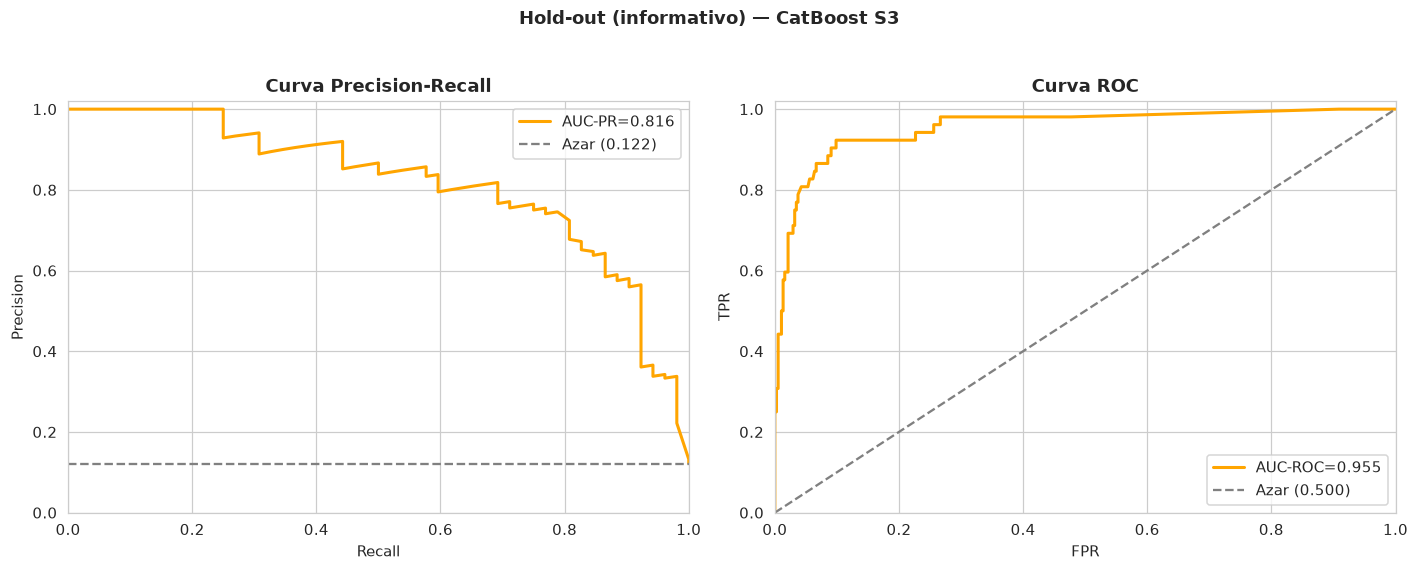

In [28]:
# Curvas PR y ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p, r, _ = precision_recall_curve(y_test, proba_ho)
axes[0].plot(r, p, color=color_campeon, lw=2, label=f'AUC-PR={metr_ho["AUC-PR"]:.3f}')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curva Precision-Recall', fontweight='bold'); axes[0].legend()
fpr, tpr, _ = roc_curve(y_test, proba_ho)
axes[1].plot(fpr, tpr, color=color_campeon, lw=2, label=f'AUC-ROC={metr_ho["AUC-ROC"]:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva ROC', fontweight='bold'); axes[1].legend(loc='lower right')
plt.suptitle(f'Hold-out (informativo) — {CAMPEON} S3', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/final_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Persistencia de artefactos

In [29]:
# ── Guardar OOF de los 3 modelos (necesarios para stacking en S4) ──
oof_dict = {}
for m in TOP_3:
    oof_dict[m] = cal_results[m]['oof_cal'].tolist()
with open(f'{DIR_DATA}/oof_probas_top3.json', 'w') as f:
    json.dump(oof_dict, f, indent=2)

# ── Guardar features seleccionadas por modelo ──
features_s3 = {m: sel_results[m]['set_s3'] for m in TOP_3}
with open(f'{DIR_DATA}/features_s3_por_modelo.json', 'w') as f:
    json.dump(features_s3, f, indent=2, ensure_ascii=False)

# ── Guardar configs del campeón ──
config_campeon = {
    'modelo': CAMPEON,
    'set_s2': campeon_cfg['set'],
    'balanceo': campeon_cfg['balanceo'],
    'features_s3': campeon_set,
    'params_s3': campeon_params,
    'calibracion': campeon_cal,
    'umbral': campeon_umbral,
    'f1_cv_s3': round(F1_CAMPEON, 4),
    'f1_oof_s3': round(cal_results[CAMPEON]['f1_oof'], 4),
}
with open(f'{DIR_DATA}/config_campeon_s3.json', 'w') as f:
    json.dump(config_campeon, f, indent=2, ensure_ascii=False)

# ── Guardar modelos calibrados de los 3 (para stacking en S4) ──
for m in TOP_3:
    sr = sel_results[m]
    opr = optuna_results[m]
    cr = cal_results[m]
    cfg_m = TOP3_CONFIG[m]
    Xtr_m = SETS_TR[cfg_m['set']][sr['set_s3']]
    modelo_cal = CalibratedClassifierCV(
        make_pipe(m, opr['params_s3'], cfg_m['balanceo']),
        method=cr['metodo_cal'], cv=5)
    modelo_cal.fit(Xtr_m, y_train)
    fname = f'{DIR_MODELS}/modelo_calibrado_{m.lower().replace(" ", "_")}.pkl'
    joblib.dump(modelo_cal, fname)
    print(f'  {fname}')

print(f'\nArtefactos S3 guardados en {OUT}/')

  outputs_sprint3/models/modelo_calibrado_catboost.pkl
  outputs_sprint3/models/modelo_calibrado_xgboost.pkl
  outputs_sprint3/models/modelo_calibrado_histgradientboosting.pkl

Artefactos S3 guardados en outputs_sprint3/


## Resumen

In [30]:
# ── Resumen JSON ──
resumen3 = {
    'sprint': 3,
    'nombre': 'SHAP + selección (1-SE) + Re-Optuna + calibración + umbral — top-3',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': 'Pipeline completo a top-3; decisión por F1_CV; hold-out una sola vez (informativo).',
    'campeon': CAMPEON,
    'f1_cv_final': round(F1_CAMPEON, 4),
    'f1_oof_final': round(cal_results[CAMPEON]['f1_oof'], 4),
    'f1_holdout': round(metr_ho['F1'], 4),
    'f1_sprint2': round(F1_SPRINT2, 4),
    'mejora_vs_sprint2': round(F1_CAMPEON - F1_SPRINT2, 4),
    'metricas_holdout': {k: round(v, 4) for k, v in metr_ho.items()},
    'top_3_pipeline': {},
    'ablacion': {
        'f1_completo': round(f1_ref, 4),
        'f1_sin_ag': round(f1_sin_ag, 4),
        'f1_sin_economicos': round(f1_sin_econ, 4),
    },
    'versiones_librerias': versiones,
}

for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr = sel_results[m]
    opr = optuna_results[m]
    cr = cal_results[m]
    lc = lc_results[m]
    resumen3['top_3_pipeline'][m] = {
        'set_s2': cfg['set'],
        'n_features_s2': len(SETS_TR[cfg['set']].columns),
        'n_features_95_shap': sr['n_95'],
        'n_features_1se': sr['n_opt'],
        'features_s3': sr['set_s3'],
        'f1_cv_s2': cfg['f1_cv'],
        'f1_cv_1se': round(sr['f1_sel'], 4),
        'f1_cv_optuna_s3': round(opr['f1_optuna'], 4),
        'f1_cv_s3': round(opr['f1_s3'], 4),
        'params_s3': opr['params_s3'],
        'origen_params': opr['origen'],
        'calibracion': cr['metodo_cal'],
        'brier_oof': {k: round(v, 5) for k, v in cr['brier'].items()},
        'umbral': round(cr['umbral'], 4),
        'f1_oof': round(cr['f1_oof'], 4),
        'gap_pre': round(lc['gap_pre'], 4),
        'gap_post': round(lc['gap_post'], 4),
    }

with open(f'{OUT}/resumen_sprint3.json', 'w') as f:
    json.dump(resumen3, f, indent=2, ensure_ascii=False)

print(coral('════════════════════ RESUMEN SPRINT 3 ════════════════════'))
print(f'Campeón: {CAMPEON}')
print(f'\nPipeline por modelo:')
for m in TOP_3:
    p = resumen3['top_3_pipeline'][m]
    marker = '' if m == CAMPEON else ''
    print(f'  {m:22s}: {p["n_features_s2"]}→{p["n_features_1se"]} feat | '
          f'F1_CV S2={p["f1_cv_s2"]:.4f}→S3={p["f1_cv_s3"]:.4f} | '
          f'cal={p["calibracion"]} | umb={p["umbral"]:.3f} | F1_OOF={p["f1_oof"]:.4f} | '
          f'gap={p["gap_post"]:.3f}{marker}')
print(f'\nAblación ({CAMPEON}):')
print(f'  Completo: {f1_ref:.4f} | Sin Ag: {f1_sin_ag:.4f} ({f1_sin_ag-f1_ref:+.4f}) | '
      f'Sin económicos: {f1_sin_econ:.4f} ({f1_sin_econ-f1_ref:+.4f})')
print(f'\nHold-out (informativo): F1={metr_ho["F1"]:.4f} | P={metr_ho["Precision"]:.4f} | '
      f'R={metr_ho["Recall"]:.4f} | AUC-PR={metr_ho["AUC-PR"]:.4f}')
print(f'\nEvolución del proyecto (F1_CV):')
print(f'   Sprint 0 = {RESUMEN_S0["f1_final"]:.4f}')
print(f'   Sprint 1 = {RESUMEN_S1["f1_final"]:.4f} ({RESUMEN_S1["f1_final"]-RESUMEN_S0["f1_final"]:+.4f})')
print(f'   Sprint 2 = {F1_SPRINT2:.4f} ({F1_SPRINT2-RESUMEN_S1["f1_final"]:+.4f})')
print(f'   Sprint 3 = {F1_CAMPEON:.4f} ({F1_CAMPEON-F1_SPRINT2:+.4f})')
print(f'\nArtefactos para Sprint 4: OOF top-3, modelos calibrados, features S3, config campeón.')

════════════════════ RESUMEN SPRINT 3 ════════════════════
Campeón: CatBoost

Pipeline por modelo:
  CatBoost              : 46→21 feat | F1_CV S2=0.7493→S3=0.7447 | cal=isotonic | umb=0.354 | F1_OOF=0.7182 | gap=0.272
  XGBoost               : 46→11 feat | F1_CV S2=0.7440→S3=0.7363 | cal=isotonic | umb=0.323 | F1_OOF=0.7226 | gap=0.249
  HistGradientBoosting  : 51→11 feat | F1_CV S2=0.7428→S3=0.7289 | cal=isotonic | umb=0.431 | F1_OOF=0.7221 | gap=0.274

Ablación (CatBoost):
  Completo: 0.7447 | Sin Ag: 0.6061 (-0.1386) | Sin económicos: 0.6126 (-0.1321)

Hold-out (informativo): F1=0.7619 | P=0.7547 | R=0.7692 | AUC-PR=0.8163

Evolución del proyecto (F1_CV):
   Sprint 0 = 0.7090
   Sprint 1 = 0.7277 (+0.0187)
   Sprint 2 = 0.7493 (+0.0216)
   Sprint 3 = 0.7447 (-0.0046)

Artefactos para Sprint 4: OOF top-3, modelos calibrados, features S3, config campeón.
